# Projectile Motion without Air Resistance

## Purpose of this notebook

Projectile motion without drag has a familiar analytical solution. That makes it an ideal **verification problem**: we can compare several numerical algorithms with a known answer before applying them to a model that cannot be solved as simply.

The emphasis is therefore not projectile physics itself. We will ask:

- How do Euler, Euler–Cromer, and an average-velocity update translate differential equations into an algorithm?
- What information is evaluated at the current time, and what is evaluated at the next time?
- How does a finite timestep affect the trajectory and the detected landing point?
- How can an analytical solution help us distinguish modeling effects from numerical error?

For motion in a uniform gravitational field,

$$\frac{dx}{dt}=v_x, \qquad \frac{dy}{dt}=v_y,$$

$$\frac{dv_x}{dt}=0, \qquad \frac{dv_y}{dt}=-g.$$

The state of the projectile is the four-component collection

$$\mathbf{s}(t)=(x(t),y(t),v_x(t),v_y(t)).$$

Specifying $\mathbf{s}(0)$ turns the differential equations into an initial-value problem. Each numerical method advances this state from $t_n$ to $t_{n+1}=t_n+\tau$.

In [11]:
from array import array
import numpy as np
import math

In [12]:
# Initial conditions
speed = 50.0       # launch speed (m/s)
theta = 45.0       # launch angle (degrees)
y1 = 2.0           # initial height (m)

# Physical constant
grav = 9.81        # gravitational acceleration (m/s^2)
Pi = math.pi

## Initial conditions and the analytical benchmark

The launch speed and angle are converted into Cartesian components,

$$v_{x0}=v_0\cos\theta, \qquad v_{y0}=v_0\sin\theta.$$

We store position, velocity, and acceleration as two-component arrays. This is a little more elaborate than using separate scalar variables, but the same organization extends naturally to forces that depend on both components—or to motion in three dimensions.

For comparison, the exact no-drag trajectory is

$$x(t)=x_0+v_{x0}t,$$

$$y(t)=y_0+v_{y0}t-\frac{1}{2}gt^2.$$

Because the projectile starts at $y_0=2\ \mathrm{m}$ rather than ground level, the positive solution of $y(t_f)=0$ is

$$t_f=\frac{v_{y0}+\sqrt{v_{y0}^2+2gy_0}}{g}.$$

The exact range is $x(t_f)$, and the exact maximum height is $y_0+v_{y0}^2/(2g)$. These are the benchmarks used below.

In [13]:
# Initial position
r1 = array('d')
# Initial velocity
v1 = array('d')
# Position as a function of time
r = array('d')
# Velocity as a function of time
v = array('d')
# Acceleration as a function of time
accel = array('d')

# Set the initial values of position and velocity
r1.append(0)
r1.append(y1)
v1.append(speed*math.cos(theta*Pi/180.0))
v1.append(speed*math.sin(theta*Pi/180.0))

# Set the first elements of the position and velocity arrays
r.append(r1[0])
r.append(r1[1])
v.append(v1[0])
v.append(v1[1])

# Set the first elements of the acceleration array (in this problem, the acceleration is constant, but in general it might not be)
accel.append(0)
accel.append(-grav)

# Analytical benchmarks for a launch from a possibly nonzero height
analytic_time = (v1[1] + math.sqrt(v1[1]**2 + 2.0*grav*r1[1]))/grav
analytic_range = r1[0] + v1[0]*analytic_time
analytic_max_y = r1[1] + v1[1]**2/(2.0*grav)

## Euler method

The forward Euler method replaces a derivative by the slope at the **beginning** of a timestep:

$$\frac{df}{dt}\bigg|_{t_n}\approx\frac{f_{n+1}-f_n}{\tau},$$

so that

$$f_{n+1}=f_n+\tau f'_n.$$

Applied to the projectile state,

$$x_{n+1}=x_n+\tau v_{x,n}, \qquad y_{n+1}=y_n+\tau v_{y,n},$$

$$v_{x,n+1}=v_{x,n}+\tau a_{x,n}, \qquad
v_{y,n+1}=v_{y,n}+\tau a_{y,n}.$$

Everything on the right-hand side is known at the current time. Geometrically, the method follows the current tangent line for one complete step. Its local truncation error is $O(\tau^2)$ and accumulated global error is generally $O(\tau)$, so halving the timestep should approximately halve the overall error.

In [14]:
tau_value = 0.2 # timestep in seconds ... set ONCE here for the whole notebook.

tau = tau_value # timestep in seconds
maxStep = 1000000 # maximum number of steps

# Create arrays to store the x and y positions and velocities as a function of time as well as the time, itself, for both the numerical method and the analytical method (NoAir).
xplot = array('d')
yplot = array('d')
xNoAir = array('d')
yNoAir = array('d')
time = array('d')
timeNoAir = array('d')

### Choosing the timestep and storage arrays

The same timestep, `tau_value`, will be used for all three methods so the comparison is fair. A large value makes their differences easy to see; a smaller value should move every numerical result toward the analytical trajectory.

At each step we store $x$, $y$, and $t$ for plotting. The arrays named `NoAir` contain the exact analytical solution evaluated at the same discrete times.

### Advancing the solution and detecting impact

The loop performs four operations repeatedly:

1. Save the current numerical state.
2. Evaluate the analytical solution at the same time.
3. Apply one Euler update.
4. Stop after the updated vertical position becomes negative.

The last condition is a simple **event detector**. It does not locate the exact time at which $y=0$; it merely detects the first sampled point below the ground. Consequently, the reported flight time and range are quantized in increments of $\tau$ and usually extend slightly beyond the physical impact. That event-location error is distinct from the integration error of the method itself.

In [15]:
endtime = 0
nelements = 0

# start looping ... we will break out of this loop when:
# a) the projectile hits the ground (y < 0)
# b) the y-velocity is negative (i.e., the projectile is moving down)
# 


for iStep in range(1,maxStep+1):
    xplot.append(r[0])
    yplot.append(r[1])
    t = (iStep-1)*tau
    timeNoAir.append(t)
    xNoAir.append(r1[0]+v1[0]*t)
    yNoAir.append(r1[1]+v1[1]*t-0.5*grav*t*t)
    accel[0]=0.0
    accel[1]=-1.0*grav
    
    # Euler Method
    r[0] = r[0] + tau*v[0]
    r[1] = r[1] + tau*v[1]
    v[0] = v[0] + tau*accel[0]
    v[1] = v[1] + tau*accel[1]
    
    # Euler-Cromer Method
    #v[0] = v[0] + tau*accel[0]
    #v[1] = v[1] + tau*accel[1]    
    #r[0] = r[0] + tau*v[0]
    #r[1] = r[1] + tau*v[1]
    
    # MidPoint Method
    # vxnew = v[0] + tau*accel[0]
    # vynew = v[1] + tau*accel[1]
    # r[0] = r[0] + tau*(v[0] + vxnew)/2.0
    # r[1] = r[1] + tau*(v[1] + vynew)/2.0
    # v[0] = vxnew
    # v[1] = vynew
    
    #print ("x = %f     vx = %f    ax = %f" %(r[0],v[0],accel[0]))
    #print ("y = %f     vy = %f    ay = %f" %(r[1],v[1],accel[1]))
    
    time.append(tau*(iStep-1))
    
    if (r[1] < 0):
        xplot.append(r[0])
        yplot.append(r[1])
        time.append(tau*iStep)
        endtime = tau*iStep
        nelements = iStep
        break
        
max_y = np.amax(yplot)+1
max_x = np.amax(xplot)+1
max_t = np.amax(time)+1

print ("Maximum range is %f meters." % r[0])
print ("Theory maximum range is %f meters." % analytic_range)
print (" ")

print ("Time of flight is %f seconds." % (max_t-1))
print ("Theory time of flight is %f seconds." % analytic_time)
print (" ")

print ("Max y = %f" % (max_y-1))
print ("Theory Max y = %f" % analytic_max_y)
print (" ")


print ("Number of elements = %d" % nelements)

Maximum range is 268.700577 meters.
Theory maximum range is 256.826544 meters.
 
Time of flight is 7.600000 seconds.
Theory time of flight is 7.264152 seconds.
 
Max y = 69.249888
Theory Max y = 65.710499
 
Number of elements = 38


### Interpreting the numerical report

Do not expect exact agreement at finite $\tau$. Two effects are mixed into the reported range and flight time:

- the accumulated error in the numerical trajectory; and
- the fact that the code stops at the first point *below* $y=0$.

A useful experiment is to run the notebook with several timestep values and tabulate the absolute error. A trustworthy numerical result should converge toward a stable value as $\tau\rightarrow0$.

### Reading the three plots

The trajectory plot, $y(x)$, gives the familiar path through space. The other two plots separate the coordinates:

- $x(t)$ tests the horizontal update. With no drag, the exact result is a straight line.
- $y(t)$ tests the vertical update. The exact result is a downward-opening parabola.

Looking at all three prevents agreement in one projection from hiding an error in another. The solid curve is the analytical benchmark and the dashed curve is the numerical result.

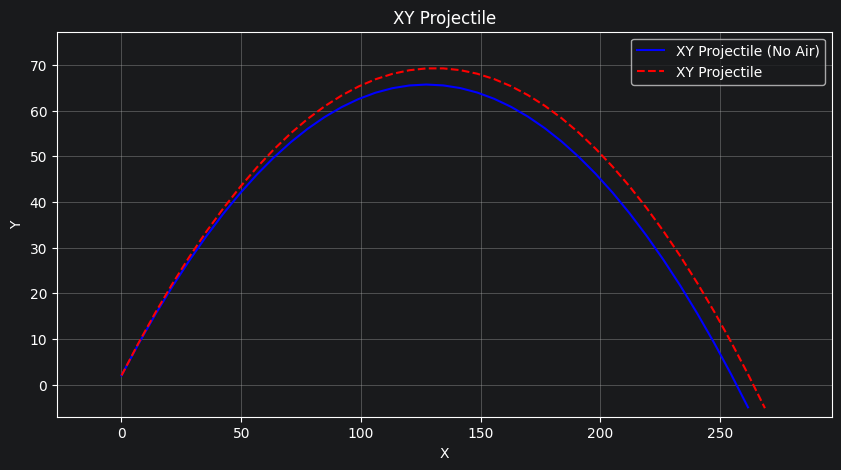

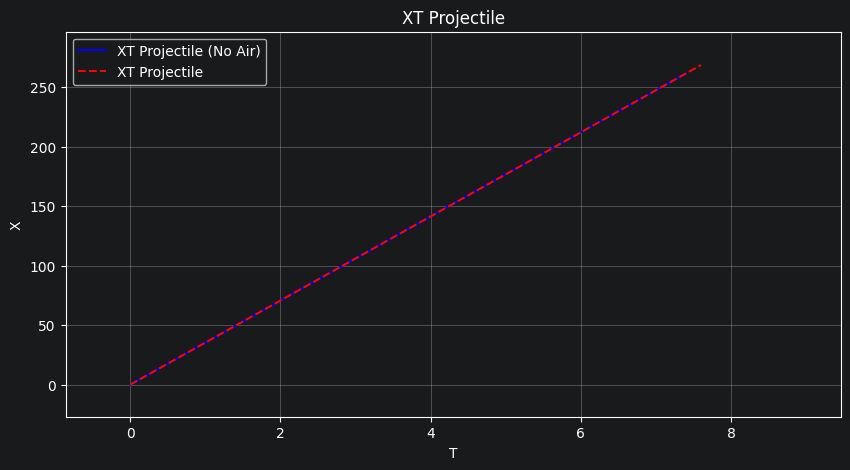

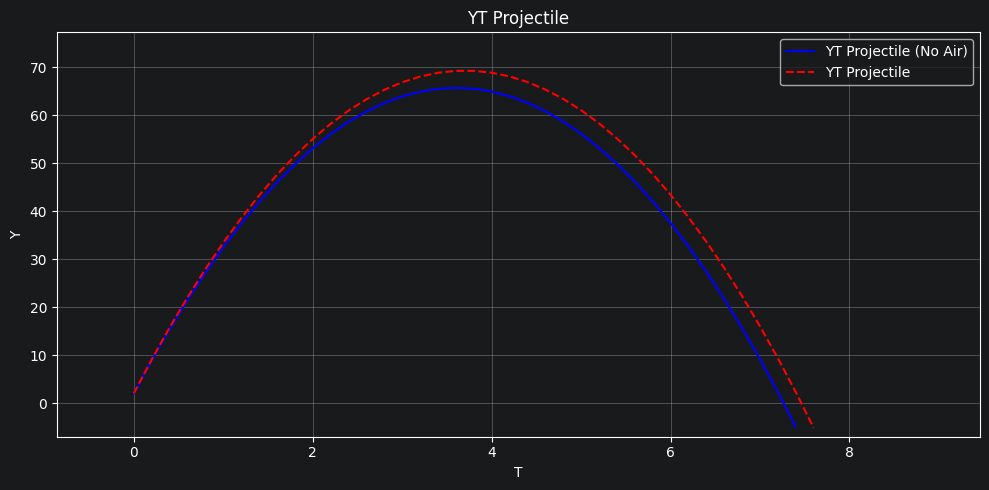

In [16]:
import matplotlib.pyplot as plt
import numpy as np

xcanvas = 1000
ycanvas = 500

# Create figures and axes for the XY projectile plot, XT projectile plot, and YT projectile plot
fig1, ax1 = plt.subplots(figsize=(xcanvas / 100, ycanvas / 100))
fig2, ax2 = plt.subplots(figsize=(xcanvas / 100, ycanvas / 100))
fig3, ax3 = plt.subplots(figsize=(xcanvas / 100, ycanvas / 100))

# Plot the XY projectile data
ax1.plot(xNoAir, yNoAir, 'b-', label='XY Projectile (No Air)')
ax1.plot(xplot, yplot, 'r--', label='XY Projectile')
ax1.set_title('XY Projectile')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_xlim(-0.1 * max_x, 1.1 * max_x)
ax1.set_ylim(-0.1 * max_y, 1.1 * max_y)
ax1.grid()
ax1.legend()

# Plot the XT projectile data
ax2.plot(timeNoAir, xNoAir, 'b-', label='XT Projectile (No Air)')
ax2.plot(time, xplot, 'r--', label='XT Projectile')
ax2.set_title('XT Projectile')
ax2.set_xlabel('T')
ax2.set_ylabel('X')
ax2.set_xlim(-0.1 * max_t, 1.1 * max_t)
ax2.set_ylim(-0.1 * max_x, 1.1 * max_x)
ax2.grid()
ax2.legend()

# Plot the YT projectile data
ax3.plot(timeNoAir, yNoAir, 'b-', label='YT Projectile (No Air)')
ax3.plot(time, yplot, 'r--', label='YT Projectile')
ax3.set_title('YT Projectile')
ax3.set_xlabel('T')
ax3.set_ylabel('Y')
ax3.set_xlim(-0.1 * max_t, 1.1 * max_t)
ax3.set_ylim(-0.1 * max_y, 1.1 * max_y)
ax3.grid()
ax3.legend()

# Show the plots
plt.tight_layout()
plt.show()

## Euler–Cromer method

Euler–Cromer uses the same velocity update as Euler but uses the **new** velocity when updating position:

$$v_{x,n+1}=v_{x,n}+\tau a_{x,n}, \qquad
v_{y,n+1}=v_{y,n}+\tau a_{y,n},$$

$$x_{n+1}=x_n+\tau v_{x,n+1}, \qquad
y_{n+1}=y_n+\tau v_{y,n+1}.$$

This small change often improves long-term behavior in oscillatory and other conservative systems. It does not make the method universally more accurate, and this one-sided Euler–Cromer update is not, by itself, time-reversible. For constant downward acceleration, Euler and Euler–Cromer bias the position in opposite directions: Euler uses a vertical velocity that is too old, whereas Euler–Cromer uses one that is too new.

In [17]:
# Initial position
r1ec = array('d')
# Initial velocity
v1ec = array('d')
# Position as a function of time
rec = array('d')
# Velocity as a function of time
vec = array('d')
# Acceleration as a function of time
accelec = array('d')

# Set the initial values of position and velocity
r1ec.append(0)
r1ec.append(y1)
v1ec.append(speed*math.cos(theta*Pi/180.0))
v1ec.append(speed*math.sin(theta*Pi/180.0))

# Set the first elements of the position and velocity arrays
rec.append(r1ec[0])
rec.append(r1ec[1])
vec.append(v1ec[0])
vec.append(v1ec[1])

# Set the first elements of the acceleration array (in this problem, the acceleration is constant, but in general it might not be)
accelec.append(0)
accelec.append(-grav)

tau = tau_value # timestep in seconds
maxStep = 1000000 # maximum number of steps

# Create arrays to store the x and y positions and velocities as a function of time as well as the time, itself, for both the numerical method and the analytical method (NoAir).
xplotec = array('d')
yplotec = array('d')
xNoAirec = array('d')
yNoAirec = array('d')
timeec  = array('d')
timeNoAirec = array('d')

endtime = 0
nelements = 0

# start looping ... we will break out of this loop when:
# a) the projectile hits the ground (y < 0)
# b) the y-velocity is negative (i.e., the projectile is moving down)
# 


for iStep in range(1,maxStep+1):
    xplotec.append(rec[0])
    yplotec.append(rec[1])
    t = (iStep-1)*tau
    timeNoAirec.append(t)
    xNoAirec.append(r1ec[0]+v1ec[0]*t)
    yNoAirec.append(r1ec[1]+v1ec[1]*t-0.5*grav*t*t)
    accelec[0]=0.0
    accelec[1]=-1.0*grav
    
    # Euler Method
    #r[0] = r[0] + tau*v[0]
    #r[1] = r[1] + tau*v[1]
    #v[0] = v[0] + tau*accel[0]
    #v[1] = v[1] + tau*accel[1]
    
    # Euler-Cromer Method
    vec[0] = vec[0] + tau*accelec[0]
    vec[1] = vec[1] + tau*accelec[1]    
    rec[0] = rec[0] + tau*vec[0]
    rec[1] = rec[1] + tau*vec[1]
    
    # MidPoint Method
    # vxnew = v[0] + tau*accel[0]
    # vynew = v[1] + tau*accel[1]
    # r[0] = r[0] + tau*(v[0] + vxnew)/2.0
    # r[1] = r[1] + tau*(v[1] + vynew)/2.0
    # v[0] = vxnew
    # v[1] = vynew
    
    #print ("x = %f     vx = %f    ax = %f" %(r[0],v[0],accel[0]))
    #print ("y = %f     vy = %f    ay = %f" %(r[1],v[1],accel[1]))
    
    timeec.append(tau*(iStep-1))
    
    if (rec[1] < 0):
        xplotec.append(rec[0])
        yplotec.append(rec[1])
        timeec.append(tau*iStep)
        endtime = tau*iStep
        nelements = iStep
        break
        
max_y = np.amax(yplotec)+1
max_x = np.amax(xplotec)+1
max_t = np.amax(timeec)+1

print ("Maximum range is %f meters." % rec[0])
print ("Theory maximum range is %f meters." % (speed*speed/grav*math.sin(2.0*theta*Pi/180.0)))
print (" ")

print ("Time of flight is %f seconds." % (max_t-1))
print ("Theory time of flight is %f seconds." % (2.0*speed/grav*math.sin(theta*Pi/180.0)))
print (" ")

print ("Max y = %f" % (max_y-1))
print ("Theory Max y = %f" % (speed*speed/(2.0*grav)*math.pow(math.sin(theta*Pi/180.0),2)))
print (" ")


print ("Number of elements = %d" % nelements)

Maximum range is 254.558441 meters.
Theory maximum range is 254.841998 meters.
 
Time of flight is 7.200000 seconds.
Theory time of flight is 7.208020 seconds.
 
Max y = 62.178821
Theory Max y = 63.710499
 
Number of elements = 36


### Comparing Euler and Euler–Cromer

The new plots retain the Euler result and add Euler–Cromer. Focus on the direction of each method's vertical error. Their opposite biases follow directly from whether $y$ is advanced with $v_{y,n}$ or $v_{y,n+1}$.

Both methods remain first-order algorithms. Reducing $\tau$ should reduce both errors, even though one method may happen to look better for a particular observable and timestep.

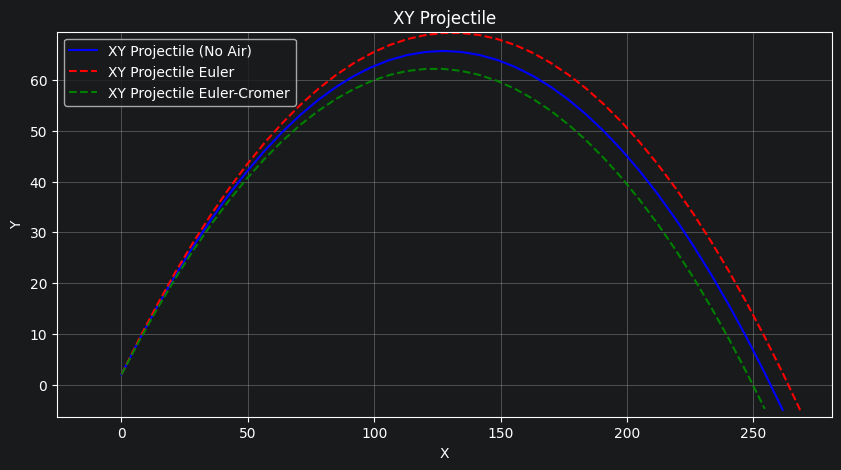

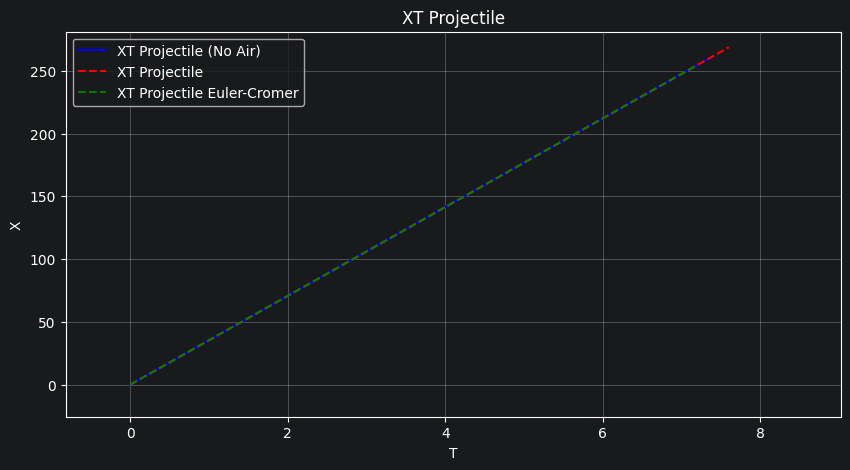

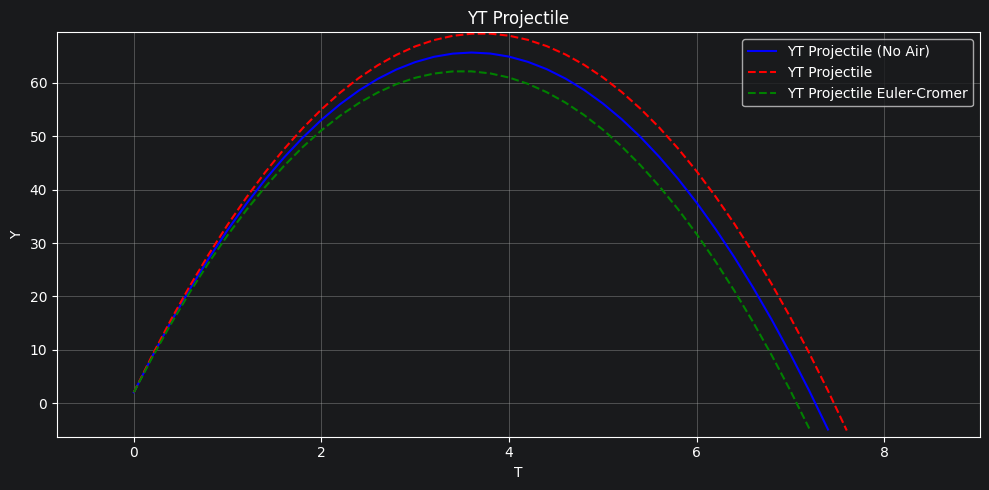

In [18]:
xcanvas = 1000
ycanvas = 500

# Create figures and axes for the XY projectile plot, XT projectile plot, and YT projectile plot
fig1, ax1 = plt.subplots(figsize=(xcanvas / 100, ycanvas / 100))
fig2, ax2 = plt.subplots(figsize=(xcanvas / 100, ycanvas / 100))
fig3, ax3 = plt.subplots(figsize=(xcanvas / 100, ycanvas / 100))

# Plot the XY projectile data
ax1.plot(xNoAir, yNoAir, 'b-', label='XY Projectile (No Air)')
ax1.plot(xplot, yplot, 'r--', label='XY Projectile Euler')
ax1.plot(xplotec, yplotec, 'g--', label='XY Projectile Euler-Cromer')
ax1.set_title('XY Projectile')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_xlim(-0.1 * max_x, 1.1 * max_x)
ax1.set_ylim(-0.1 * max_y, 1.1 * max_y)
ax1.grid()
ax1.legend()

# Plot the XT projectile data
ax2.plot(timeNoAir, xNoAir, 'b-', label='XT Projectile (No Air)')
ax2.plot(time, xplot, 'r--', label='XT Projectile')
ax2.plot(timeec, xplotec, 'g--', label='XT Projectile Euler-Cromer')
ax2.set_title('XT Projectile')
ax2.set_xlabel('T')
ax2.set_ylabel('X')
ax2.set_xlim(-0.1 * max_t, 1.1 * max_t)
ax2.set_ylim(-0.1 * max_x, 1.1 * max_x)
ax2.grid()
ax2.legend()

# Plot the YT projectile data
ax3.plot(timeNoAir, yNoAir, 'b-', label='YT Projectile (No Air)')
ax3.plot(time, yplot, 'r--', label='YT Projectile')
ax3.plot(timeec, yplotec, 'g--', label='YT Projectile Euler-Cromer')
ax3.set_title('YT Projectile')
ax3.set_xlabel('T')
ax3.set_ylabel('Y')
ax3.set_xlim(-0.1 * max_t, 1.1 * max_t)
ax3.set_ylim(-0.1 * max_y, 1.1 * max_y)
ax3.grid()
ax3.legend()

# Show the plots
plt.tight_layout()
plt.show()

## Average-velocity (midpoint) position update

The third algorithm first predicts the velocity at the endpoint,

$$\mathbf{v}_{n+1}=\mathbf{v}_n+\tau\mathbf{a}_n,$$

and then advances position using the average of the old and new velocities:

$$\mathbf{r}_{n+1}=\mathbf{r}_n+
\tau\frac{\mathbf{v}_n+\mathbf{v}_{n+1}}{2}.$$

For constant acceleration this becomes

$$\mathbf{r}_{n+1}=\mathbf{r}_n+\tau\mathbf{v}_n+
\frac{1}{2}\tau^2\mathbf{a},$$

which is exactly the analytical constant-acceleration position update. Thus the trajectory is exact at the sampled times, apart from floating-point roundoff. The reported landing point can still overshoot because the event detector checks only at the ends of timesteps.

This notebook calls the update the “midpoint method” because the average velocity represents the velocity at the temporal midpoint when acceleration is constant. For a velocity-dependent force, a full second-order midpoint method must also evaluate the acceleration at an estimated midpoint; that distinction becomes important in the drag notebook.

In [19]:
# Initial position
r1mp = array('d')
# Initial velocity
v1mp = array('d')
# Position as a function of time
rmp = array('d')
# Velocity as a function of time
vmp = array('d')
# Acceleration as a function of time
accelmp = array('d')

# Set the initial values of position and velocity
r1mp.append(0)
r1mp.append(y1)
v1mp.append(speed*math.cos(theta*Pi/180.0))
v1mp.append(speed*math.sin(theta*Pi/180.0))

# Set the first elements of the position and velocity arrays
rmp.append(r1mp[0])
rmp.append(r1mp[1])
vmp.append(v1mp[0])
vmp.append(v1mp[1])

# Set the first elements of the acceleration array (in this problem, the acceleration is constant, but in general it might not be)
accelmp.append(0)
accelmp.append(-grav)

tau = tau_value # timestep in seconds
maxStep = 1000000 # maximum number of steps

# Create arrays to store the x and y positions and velocities as a function of time as well as the time, itself, for both the numerical method and the analytical method (NoAir).
xplotmp = array('d')
yplotmp = array('d')
xNoAirmp = array('d')
yNoAirmp = array('d')
timemp  = array('d')
timeNoAirmp = array('d')

endtime = 0
nelements = 0

# start looping ... we will break out of this loop when:
# a) the projectile hits the ground (y < 0)
# b) the y-velocity is negative (i.e., the projectile is moving down)
# 


for iStep in range(1,maxStep+1):
    xplotmp.append(rmp[0])
    yplotmp.append(rmp[1])
    t = (iStep-1)*tau
    timeNoAirmp.append(t)
    xNoAirmp.append(r1mp[0]+v1mp[0]*t)
    yNoAirmp.append(r1mp[1]+v1mp[1]*t-0.5*grav*t*t)
    accelmp[0]=0.0
    accelmp[1]=-1.0*grav
    
    # Euler Method
    #r[0] = r[0] + tau*v[0]
    #r[1] = r[1] + tau*v[1]
    #v[0] = v[0] + tau*accel[0]
    #v[1] = v[1] + tau*accel[1]
    
    # Euler-Cromer Method
    #vec[0] = vec[0] + tau*accelec[0]
    #vec[1] = vec[1] + tau*accelec[1]    
    #rec[0] = rec[0] + tau*vec[0]
    #rec[1] = rec[1] + tau*vec[1]
    
    # MidPoint Method
    vxnew = vmp[0] + tau*accelmp[0]
    vynew = vmp[1] + tau*accelmp[1]
    rmp[0] = rmp[0] + tau*(vmp[0] + vxnew)/2.0
    rmp[1] = rmp[1] + tau*(vmp[1] + vynew)/2.0
    vmp[0] = vxnew
    vmp[1] = vynew
    
    #print ("x = %f     vx = %f    ax = %f" %(rmp[0],vmp[0],accelmp[0]))
    #print ("y = %f     vy = %f    ay = %f" %(rmp[1],vmp[1],accelmp[1]))
    
    timemp.append(tau*(iStep-1))
    
    if (rmp[1] < 0):
        xplotmp.append(rmp[0])
        yplotmp.append(rmp[1])
        timemp.append(tau*iStep)
        endtime = tau*iStep
        nelements = iStep
        break
        
max_y = np.amax(yplotmp)+1
max_x = np.amax(xplotmp)+1
max_t = np.amax(timemp)+1

print ("Maximum range is %f meters." % rmp[0])
print ("Theory maximum range is %f meters." % (speed*speed/grav*math.sin(2.0*theta*Pi/180.0)))
print (" ")

print ("Time of flight is %f seconds." % (max_t-1))
print ("Theory time of flight is %f seconds." % (2.0*speed/grav*math.sin(theta*Pi/180.0)))
print (" ")

print ("Max y = %f" % (max_y-1))
print ("Theory Max y = %f" % (speed*speed/(2.0*grav)*math.pow(math.sin(theta*Pi/180.0),2)))
print (" ")


print ("Number of elements = %d" % nelements)

Maximum range is 261.629509 meters.
Theory maximum range is 254.841998 meters.
 
Time of flight is 7.400000 seconds.
Theory time of flight is 7.208020 seconds.
 
Max y = 65.710421
Theory Max y = 63.710499
 
Number of elements = 37


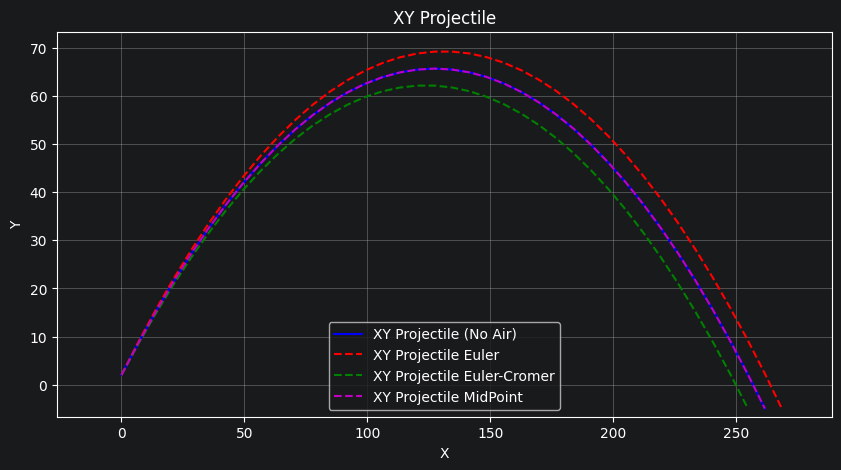

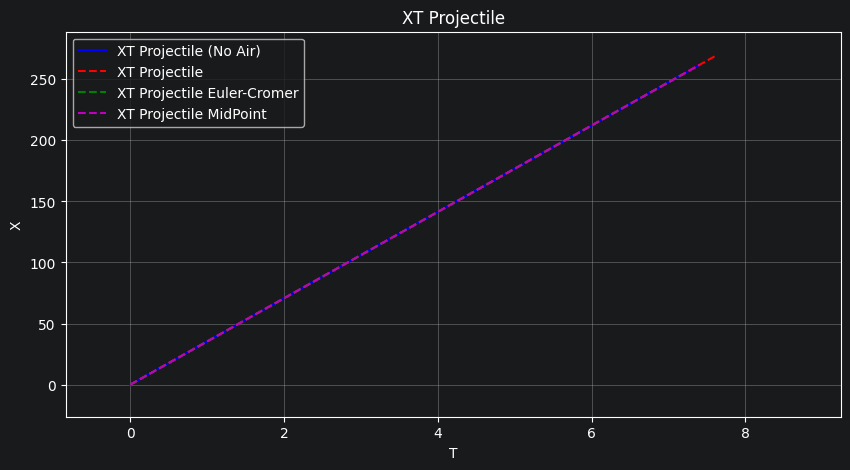

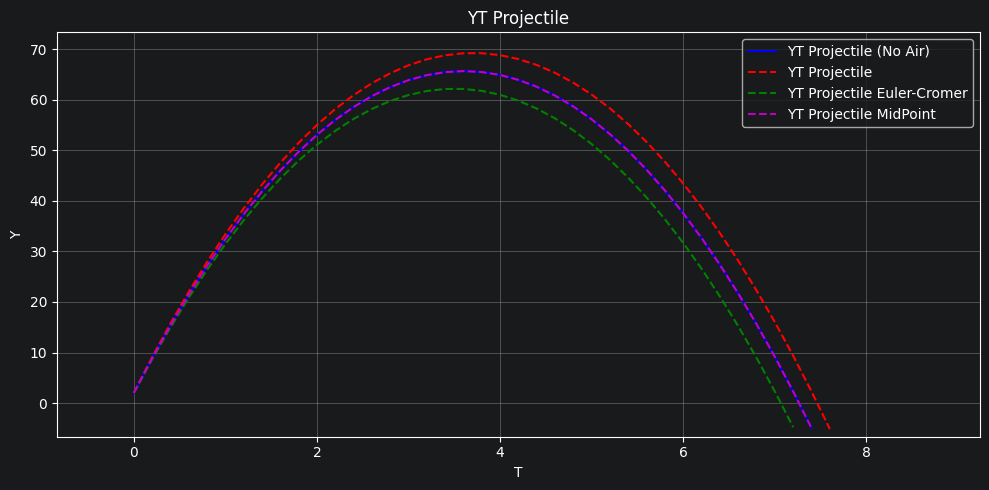

In [20]:
xcanvas = 1000
ycanvas = 500

# Create figures and axes for the XY projectile plot, XT projectile plot, and YT projectile plot
fig1, ax1 = plt.subplots(figsize=(xcanvas / 100, ycanvas / 100))
fig2, ax2 = plt.subplots(figsize=(xcanvas / 100, ycanvas / 100))
fig3, ax3 = plt.subplots(figsize=(xcanvas / 100, ycanvas / 100))

# Plot the XY projectile data
ax1.plot(xNoAir, yNoAir, 'b-', label='XY Projectile (No Air)')
ax1.plot(xplot, yplot, 'r--', label='XY Projectile Euler')
ax1.plot(xplotec, yplotec, 'g--', label='XY Projectile Euler-Cromer')
ax1.plot(xplotmp, yplotmp, 'm--', label='XY Projectile MidPoint')
ax1.set_title('XY Projectile')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_xlim(-0.1 * max_x, 1.1 * max_x)
ax1.set_ylim(-0.1 * max_y, 1.1 * max_y)
ax1.grid()
ax1.legend()

# Plot the XT projectile data
ax2.plot(timeNoAir, xNoAir, 'b-', label='XT Projectile (No Air)')
ax2.plot(time, xplot, 'r--', label='XT Projectile')
ax2.plot(timeec, xplotec, 'g--', label='XT Projectile Euler-Cromer')
ax2.plot(timemp, xplotmp, 'm--', label='XT Projectile MidPoint')
ax2.set_title('XT Projectile')
ax2.set_xlabel('T')
ax2.set_ylabel('X')
ax2.set_xlim(-0.1 * max_t, 1.1 * max_t)
ax2.set_ylim(-0.1 * max_x, 1.1 * max_x)
ax2.grid()
ax2.legend()

# Plot the YT projectile data
ax3.plot(timeNoAir, yNoAir, 'b-', label='YT Projectile (No Air)')
ax3.plot(time, yplot, 'r--', label='YT Projectile')
ax3.plot(timeec, yplotec, 'g--', label='YT Projectile Euler-Cromer')
ax3.plot(timemp, yplotmp, 'm--', label='YT Projectile MidPoint')
ax3.set_title('YT Projectile')
ax3.set_xlabel('T')
ax3.set_ylabel('Y')
ax3.set_xlim(-0.1 * max_t, 1.1 * max_t)
ax3.set_ylim(-0.1 * max_y, 1.1 * max_y)
ax3.grid()
ax3.legend()

# Show the plots
plt.tight_layout()
plt.show()

## Conclusions and suggested investigation

| Method | Velocity used for position | General global order | Behavior in this problem |
|---|---|---:|---|
| Euler | beginning of step | $O(\tau)$ | vertical position is biased high |
| Euler–Cromer | end of step | $O(\tau)$ | vertical position is biased low |
| Average velocity | mean of beginning and end | exact here at sampled times | constant-acceleration trajectory is reproduced |

The analytical solution makes these claims testable rather than qualitative. Try several values of `tau_value`, such as 0.4, 0.2, 0.1, and 0.05 s. For each method, record the error in range or height. Ask whether the error decreases at the rate predicted by the method's order.

The next notebook adds quadratic air resistance. That changes both the physical model and the numerical problem: acceleration will depend on velocity, the analytical benchmark will no longer be available, and the average-velocity update will no longer be exact.